# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Question and Goal**

The dealership wants to know which used-car characteristics are associated with higher or lower prices. I frame this as a supervised regression problem where `price` is the target and the predictors are vehicle details such as year, odometer, manufacturer, condition, fuel, title status, transmission, drive, type, paint color, and state.

The business goal is to explain price drivers in plain language so used car dealers can make better inventory, pricing, and listing-quality decisions.

**Evaluation plan**

I compare three simple regression models: Linear Regression as the baseline, Ridge for light regularization, and Lasso as another regularized option. I use MAE as the main metric because it is easy to explain as the average pricing error in dollars; RMSE and R-squared provide extra context about larger errors and overall fit.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# Use one random seed so sampling and train/test splitting are reproducible.
RANDOM_STATE = 42

In [3]:
data = pd.read_csv('data/vehicles.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
data.shape

(426880, 18)

In [6]:
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [8]:
data["model"].value_counts().head(20)

model
f-150             8009
silverado 1500    5140
1500              4211
camry             3135
silverado         3023
accord            2969
wrangler          2848
civic             2799
altima            2779
escape            2746
2500              2687
tacoma            2582
explorer          2499
grand cherokee    2489
corolla           2241
mustang           2225
fusion            1979
equinox           1972
cr-v              1930
focus             1832
Name: count, dtype: int64

The model column contains many specific and overlapping vehicle names, so I did not include it in the starter model to keep the analysis simple. Cleaning and grouping model names can be saved as a future improvement.

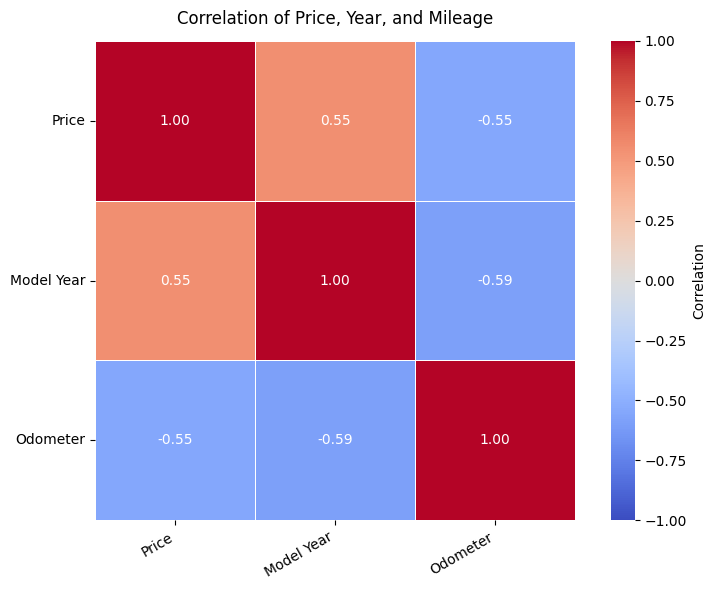

In [9]:
# Correlation matrix for numeric fields after filtering obvious listing errors.
# This keeps the visual focused on normal used-car listings instead of extreme outliers.
corr_data = data[
    data["price"].between(500, 100000)
    & data["year"].between(1980, 2022)
    & data["odometer"].between(100, 300000)
][["price", "year", "odometer"]].rename(
    columns={
        "price": "Price",
        "year": "Model Year",
        "odometer": "Odometer",
    }
)

correlations = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation of Price, Year, and Mileage", pad=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Notes:** The numeric summary shows important quality issues: some listings have zero prices, extremely high prices, missing year/odometer values, and many missing categorical fields. These issues explain why the modeling dataset is cleaned before fitting regression models.

The correlation heatmap gives a quick view of numeric relationships, while the filtered histograms and scatterplot make the price, model year, and mileage patterns easier to read. Because most vehicle details are categorical, I also use median-price summaries later to support the coefficient interpretation.

In [10]:
# Missing-value rates show which columns need cleaning or imputation.
missing_summary = (
    data.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ["column", "missing_percent"]
missing_summary.head(15)

,column,missing_percent
0,size,71.767476
1,cylinders,41.622470
2,condition,40.785232
3,VIN,37.725356
4,drive,30.586347
5,paint_color,30.501078
6,type,21.752717
7,manufacturer,4.133714
8,title_status,1.930753
9,model,1.236179


**Missing-value interpretation:** Several useful categorical fields have high missing rates, especially `size`, `cylinders`, `condition`, `drive`, and `paint_color`.

For the starter model, I keep these columns and impute missing values as `unknown` so missingness is handled consistently without dropping too many rows.

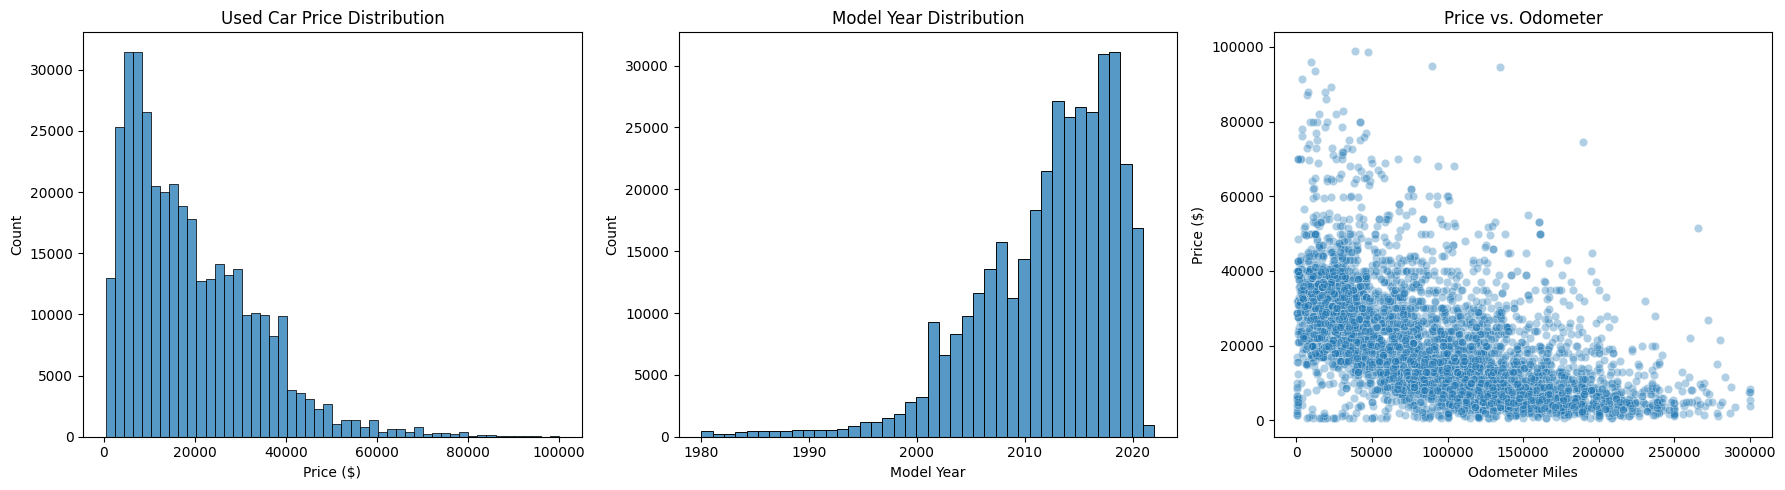

In [11]:
# Filter only for visualization so outliers do not hide the main patterns.
eda_data = data[
    data["price"].between(500, 100000)
    & data["year"].between(1980, 2022)
    & data["odometer"].between(100, 300000)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(eda_data["price"], bins=50, ax=axes[0])
axes[0].set_title("Used Car Price Distribution")
axes[0].set_xlabel("Price ($)")

sns.histplot(eda_data["year"], bins=40, ax=axes[1])
axes[1].set_title("Model Year Distribution")
axes[1].set_xlabel("Model Year")

sns.scatterplot(
    data=eda_data.sample(min(5000, len(eda_data)), random_state=RANDOM_STATE),
    x="odometer",
    y="price",
    alpha=0.35,
    ax=axes[2],
)
axes[2].set_title("Price vs. Odometer")
axes[2].set_xlabel("Odometer Miles")
axes[2].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

**Visual interpretation:** Most used-car prices are concentrated below about $40,000, and the dataset contains many newer vehicles from the 2010s and early 2020s.

The odometer scatterplot shows a clear downward pattern, suggesting that higher mileage is generally associated with lower price.

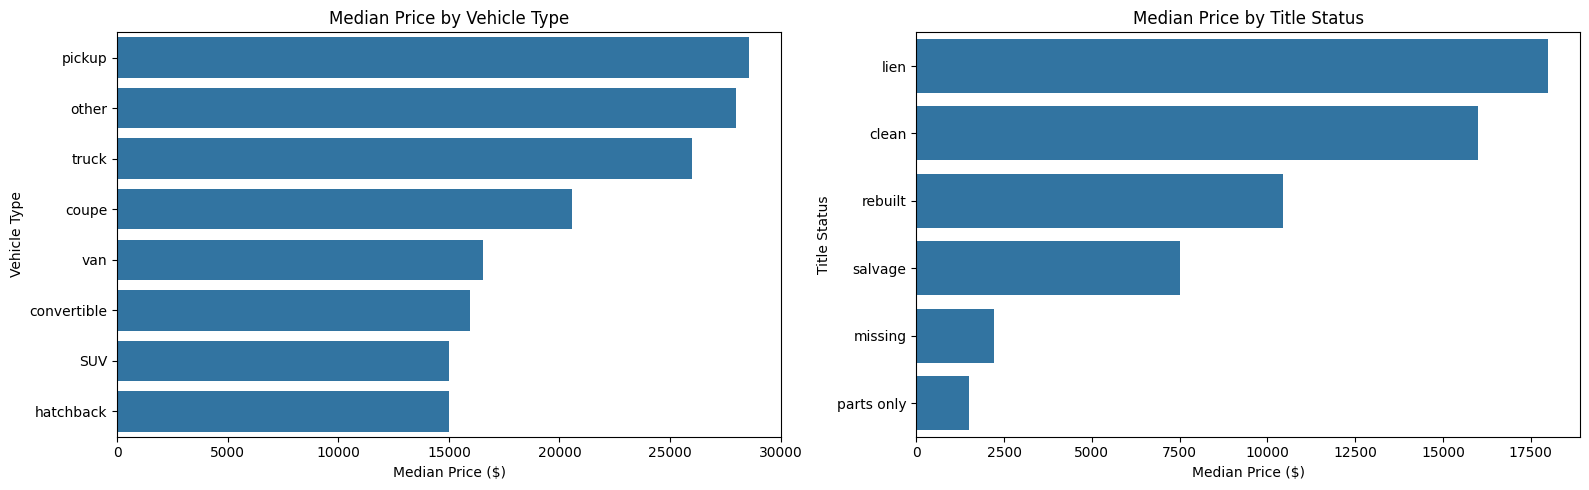

In [12]:
# Compare median prices across categorical features that are useful for dealers.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_order = (
    eda_data.groupby("type")["price"]
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index
)
sns.barplot(
    data=eda_data[eda_data["type"].isin(type_order)],
    x="price",
    y="type",
    estimator=np.median,
    order=type_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Median Price by Vehicle Type")
axes[0].set_xlabel("Median Price ($)")
axes[0].set_ylabel("Vehicle Type")

title_order = (
    eda_data.groupby("title_status")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.barplot(
    data=eda_data,
    x="price",
    y="title_status",
    estimator=np.median,
    order=title_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Median Price by Title Status")
axes[1].set_xlabel("Median Price ($)")
axes[1].set_ylabel("Title Status")

plt.tight_layout()
plt.show()

**Categorical visual interpretation:** The vehicle type chart supports the finding that pickups and trucks have stronger median prices than many passenger-car body types. The title status chart supports the recommendation to be cautious with salvage, missing-title, or parts-only vehicles because their median prices are much lower.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Data preparation approach**

I keep the original data unchanged and create a cleaned modeling table. The preparation removes identifiers, filters implausible target and mileage values, creates `vehicle_age`, groups rare categorical values, and uses pipelines for imputation, scaling, and one-hot encoding.

This keeps the workflow organized and reduces data leakage because preprocessing is fit inside the training folds during cross-validation.

In [13]:
# Import regression, preprocessing, and model-selection tools.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [14]:
# Work from a copy so the raw data and earlier EDA stay intact.
clean_data = data.copy()

# Drop identifiers and overly detailed text fields for this starter model.
clean_data = clean_data.drop(columns=["id", "VIN", "model", "region"], errors="ignore")

# Remove likely listing errors found during data understanding.
clean_data = clean_data[clean_data["price"].between(500, 100000)]
clean_data = clean_data[clean_data["year"].between(1980, 2022)]
clean_data = clean_data[clean_data["odometer"].between(100, 300000)]

# Keep rows with the core fields needed for price modeling.
required_columns = ["manufacturer", "fuel", "transmission", "title_status", "year", "odometer", "price"]
clean_data = clean_data.dropna(subset=required_columns)

# Use the newest model year in the cleaned data as the reference year for vehicle age.
reference_year = int(clean_data["year"].max())
clean_data["vehicle_age"] = reference_year - clean_data["year"]

# log1p means log(1 + x); it reduces skew in price and mileage while safely handling zeros.
clean_data["odometer_log"] = np.log1p(clean_data["odometer"])
clean_data["price_log"] = np.log1p(clean_data["price"])

print(f"Reference year used for vehicle age: {reference_year}")
clean_data.shape

Reference year used for vehicle age: 2022


(346436, 17)

In [15]:
numeric_features = ["vehicle_age", "odometer", "odometer_log"]
categorical_features = [
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "size",
    "type",
    "paint_color",
    "state",
]

# Keep only the fields used for modeling.
model_data = clean_data[numeric_features + categorical_features + ["price", "price_log"]].copy()

# Sample for faster classroom execution while keeping enough rows for stable patterns.
max_model_rows = 50000
if len(model_data) > max_model_rows:
    model_data = model_data.sample(max_model_rows, random_state=RANDOM_STATE)

# Group rare categories so cross-validation does not create unseen-category warnings.
min_category_count = 100
for column in categorical_features:
    model_data[column] = model_data[column].fillna("unknown")
    category_counts = model_data[column].value_counts()
    common_categories = category_counts[category_counts >= min_category_count].index
    model_data[column] = np.where(
        model_data[column].isin(common_categories),
        model_data[column],
        "other_low_count",
    )

X = model_data[numeric_features + categorical_features]
y = model_data["price_log"]

# Hold out 20% of the data for final model evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")

Training rows: 40,000
Test rows: 10,000


In [16]:
# Pipelines keep imputation, scaling, and one-hot encoding inside each model fit.
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=True)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("onehot", one_hot),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

**Modeling approach**

The modeling is intentionally simple and limited to methods covered in the program. Linear Regression provides the baseline, while Ridge and Lasso show whether regularization improves performance; the grid search only tunes regularization strength (`alpha`).

In [17]:
models = {
    "Linear Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", LinearRegression())]
    ),
    "Ridge Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", Ridge())]
    ),
    "Lasso Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", Lasso(max_iter=10000))]
    ),
}

# Cross-validation estimates performance on unseen data before using the test set.
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for model_name, model_pipeline in models.items():
    scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )
    cv_results.append(
        {
            "model": model_name,
            "mean_cv_mae_log_price": -scores.mean(),
            "std_cv_mae_log_price": scores.std(),
        }
    )

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_cv_mae_log_price")
cv_results_df

,model,mean_cv_mae_log_price,std_cv_mae_log_price
0,Linear Regression,0.312462,0.000166
1,Ridge Regression,0.312472,0.000172
2,Lasso Regression,0.716827,0.002507


**Interpretation:** The cross-validation results show that Linear Regression and Ridge Regression perform almost the same, with the lowest average MAE on log price. Lasso performs much worse, suggesting it removes or shrinks too many useful features for this dataset.

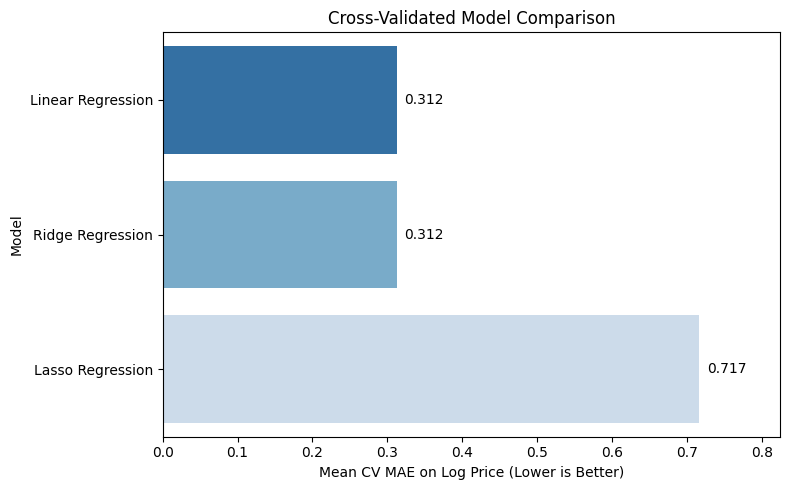

In [18]:
# Visualize model selection: lower cross-validated MAE is better.
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cv_results_df,
    x="mean_cv_mae_log_price",
    y="model",
    hue="model",
    palette="Blues_r",
    legend=False,
)
plt.title("Cross-Validated Model Comparison")
plt.xlabel("Mean CV MAE on Log Price (Lower is Better)")
plt.ylabel("Model")
plt.xlim(0, cv_results_df["mean_cv_mae_log_price"].max() * 1.15)
for index, row in cv_results_df.reset_index(drop=True).iterrows():
    plt.text(
        row["mean_cv_mae_log_price"] + 0.01,
        index,
        f'{row["mean_cv_mae_log_price"]:.3f}',
        va="center",
    )
plt.tight_layout()
plt.show()

**Model selection visual:** This chart compares the average cross-validated error for the simple regression models. The best model is the one with the smallest MAE, while Lasso's higher error suggests that its stronger feature shrinkage is not the best fit for this starter model.

In [19]:
# Tune only alpha so the model remains simple and interpretable.
ridge_search = GridSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    cv=cv,
    scoring="neg_mean_absolute_error",
)

lasso_search = GridSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", Lasso(max_iter=10000))]),
    param_grid={"model__alpha": [0.0005, 0.001, 0.005, 0.01]},
    cv=cv,
    scoring="neg_mean_absolute_error",
)

ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)

grid_results = pd.DataFrame(
    [
        {
            "model": "Ridge Regression",
            "best_alpha": ridge_search.best_params_["model__alpha"],
            "best_cv_mae_log_price": -ridge_search.best_score_,
        },
        {
            "model": "Lasso Regression",
            "best_alpha": lasso_search.best_params_["model__alpha"],
            "best_cv_mae_log_price": -lasso_search.best_score_,
        },
    ]
)

grid_results.sort_values("best_cv_mae_log_price")


,model,best_alpha,best_cv_mae_log_price
0,Ridge Regression,0.1000,0.312454
1,Lasso Regression,0.0005,0.315184


**Interpretation:** The grid search results show that Ridge Regression has the lower cross-validated MAE after tuning alpha, so it is the better regularized model. The best Ridge alpha is `0.1`, meaning only light regularization was needed.

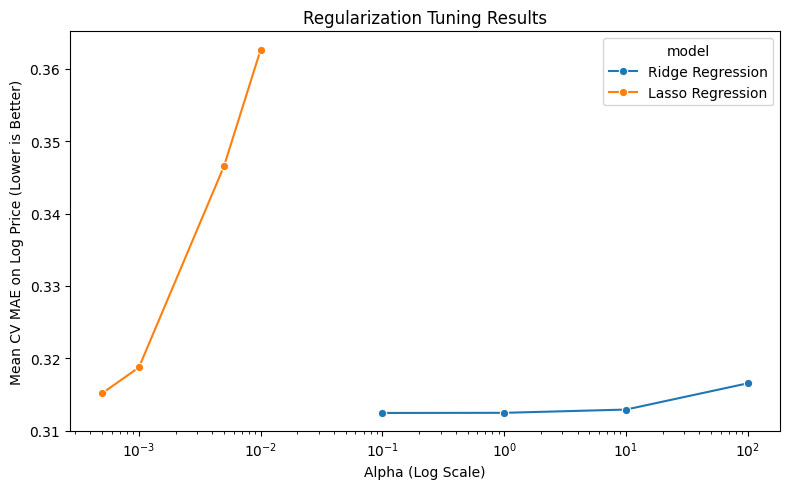

In [20]:
# Visualize improvement from tuning the regularization strength.
ridge_tuning = pd.DataFrame(ridge_search.cv_results_)
ridge_tuning["model"] = "Ridge Regression"
ridge_tuning["alpha"] = ridge_tuning["param_model__alpha"].astype(float)
ridge_tuning["mean_cv_mae_log_price"] = -ridge_tuning["mean_test_score"]

lasso_tuning = pd.DataFrame(lasso_search.cv_results_)
lasso_tuning["model"] = "Lasso Regression"
lasso_tuning["alpha"] = lasso_tuning["param_model__alpha"].astype(float)
lasso_tuning["mean_cv_mae_log_price"] = -lasso_tuning["mean_test_score"]

tuning_results = pd.concat([ridge_tuning, lasso_tuning], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=tuning_results,
    x="alpha",
    y="mean_cv_mae_log_price",
    hue="model",
    marker="o",
)
plt.xscale("log")
plt.title("Regularization Tuning Results")
plt.xlabel("Alpha (Log Scale)")
plt.ylabel("Mean CV MAE on Log Price (Lower is Better)")
plt.tight_layout()
plt.show()

**Improvement visual:** This visual shows how the regularization strength (`alpha`) affects model performance. Ridge stays more stable with lower cross-validated error, while Lasso performs worse as alpha increases, so Ridge is the better regularized option for this starter model.

In [21]:
# Select the regularized model with the lowest cross-validated MAE.
best_search = ridge_search if ridge_search.best_score_ >= lasso_search.best_score_ else lasso_search
best_model_name = "Ridge Regression" if best_search is ridge_search else "Lasso Regression"
best_model = best_search.best_estimator_

best_model_name

'Ridge Regression'

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Evaluation approach**

The best model is evaluated on the held-out test set so the final metrics are not based on the same data used for model selection. Because the model predicts log price, I convert predictions back to dollars before reporting MAE and RMSE, then review coefficients to identify the strongest price associations.

In [22]:
best_model.fit(X_train, y_train)
y_pred_log = best_model.predict(X_test)

# Convert log-price predictions back to dollars for business interpretation.
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)

evaluation_metrics = pd.DataFrame(
    [
        {
            "best_model": best_model_name,
            "test_mae_dollars": mean_absolute_error(y_test_dollars, y_pred_dollars),
            "test_rmse_dollars": np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars)),
            "test_r2_log_price": r2_score(y_test, y_pred_log),
        }
    ]
)

evaluation_metrics

,best_model,test_mae_dollars,test_rmse_dollars,test_r2_log_price
0,Ridge Regression,4932.053105,7808.092368,0.68468


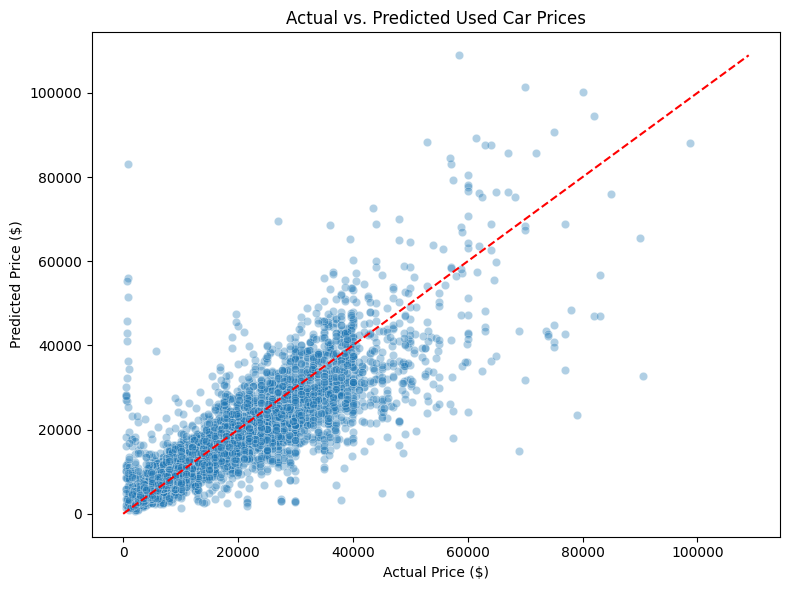

In [23]:
# The diagonal line marks perfect prediction; points near it are better predictions.
prediction_check = pd.DataFrame(
    {"actual_price": y_test_dollars, "predicted_price": y_pred_dollars}
).sample(min(5000, len(y_test_dollars)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=prediction_check, x="actual_price", y="predicted_price", alpha=0.35)
max_price = prediction_check[["actual_price", "predicted_price"]].max().max()
plt.plot([0, max_price], [0, max_price], color="red", linestyle="--")
plt.title("Actual vs. Predicted Used Car Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.tight_layout()
plt.show()

**Visual interpretation:** The points generally follow the diagonal line, so the model captures the overall relationship between actual and predicted prices. The wider spread at higher prices shows the model is less reliable for expensive vehicles.

In [24]:
# Extract coefficients so the model can be interpreted.
cat_encoder = (
    best_model.named_steps["preprocess"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

try:
    categorical_names = cat_encoder.get_feature_names_out(categorical_features)
except AttributeError:
    categorical_names = cat_encoder.get_feature_names(categorical_features)

feature_names = numeric_features + list(categorical_names)
coefficients = best_model.named_steps["model"].coef_

coef_table = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient_log_price": coefficients,
    }
)
coef_table["absolute_value"] = coef_table["coefficient_log_price"].abs()

# Show strongest positive and negative associations with predicted price.
top_positive = coef_table.sort_values("coefficient_log_price", ascending=False).head(15)
top_negative = coef_table.sort_values("coefficient_log_price").head(15)

display(top_positive)
display(top_negative)

,feature,coefficient_log_price,absolute_value
29,manufacturer_porsche,0.525606,0.525606
34,manufacturer_tesla,0.422253,0.422253
73,type_other_low_count,0.274394,0.274394
74,type_pickup,0.190229,0.190229
68,type_convertible,0.186471,0.186471
76,type_truck,0.174819,0.174819
72,type_other,0.158648,0.158648
59,transmission_manual,0.157815,0.157815
19,manufacturer_lexus,0.139162,0.139162
78,type_van,0.127475,0.127475


,feature,coefficient_log_price,absolute_value
42,condition_other_low_count,-0.922577,0.922577
51,fuel_electric,-0.774758,0.774758
38,condition_fair,-0.718118,0.718118
53,fuel_hybrid,-0.692016,0.692016
44,cylinders_4 cylinders,-0.688800,0.688800
52,fuel_gas,-0.680779,0.680779
45,cylinders_5 cylinders,-0.678879,0.678879
49,cylinders_other_low_count,-0.639652,0.639652
48,cylinders_other,-0.611171,0.611171
32,manufacturer_saturn,-0.605236,0.605236


In [25]:
# Median-price summaries support the coefficient interpretation in plain language.
for column in ["condition", "fuel", "transmission", "drive", "type", "title_status"]:
    display(
        clean_data.groupby(column)["price"]
        .agg(["count", "median"])
        .sort_values("median", ascending=False)
        .head(10)
    )

,count,median
condition,,
good,110377,21590.0
new,644,17000.0
like new,18253,14900.0
excellent,80765,11975.0
fair,5241,2600.0
salvage,443,2000.0


,count,median
fuel,,
diesel,21243,33990.0
other,26047,27990.0
electric,1449,25995.0
gas,293127,13995.0
hybrid,4570,13000.0


,count,median
transmission,,
other,57634,28990.0
automatic,271368,13000.0
manual,17434,9990.0


,count,median
drive,,
4wd,109440,21500.0
rwd,45241,19590.0
fwd,89554,10750.0


,count,median
type,,
pickup,38595,28590.0
other,17862,28590.0
truck,26434,26000.0
coupe,14827,21888.0
van,6776,16496.5
convertible,6029,16000.0
SUV,63418,14999.0
hatchback,14079,14990.0
bus,254,14900.0


,count,median
title_status,,
lien,1312,18000.0
clean,334561,16000.0
rebuilt,6676,10416.5
salvage,3529,7500.0
missing,270,2200.0
parts only,88,1500.0


**Evaluation interpretation**

Linear Regression and Ridge Regression had very similar cross-validation results, and the tuned Ridge model was selected because it keeps performance strong while adding light regularization. On the test set, Ridge had MAE about 4,932 dollars, RMSE about 7,808 dollars, and log-price R-squared about 0.685, so it captures a meaningful amount of price variation.

The actual-vs-predicted plot shows that predictions generally follow the diagonal line, but the spread gets wider for higher-priced vehicles. Coefficients show direction and relative importance, while the median-price tables translate those patterns into plain language for the dealership.

**Descriptive and inferential statistics interpretation**

Descriptive statistics in this notebook include missing-value rates, filtered distributions, correlations, and median-price summaries by category. Inferential support comes from cross-validation and the held-out test set, which estimate how well the regression models are likely to perform on listings not used to fit the model.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**Deployment summary for the dealership**

The model should be used as a pricing support tool, not an automatic pricing rule. The main message for the dealership is that age, mileage, title status, body type, drivetrain, fuel type, and manufacturer are useful pricing signals.

**Initial findings**

- Newer vehicles and lower odometer readings are generally associated with higher prices.
- Clean title vehicles are more valuable than salvage, missing-title, or parts-only vehicles.
- Pickup and truck listings show stronger median prices than many passenger-car body types.
- Diesel, 4wd, and some premium manufacturers tend to be associated with higher prices.
- Missing listing details are a business issue because incomplete condition, drive, size, type, or color values reduce pricing confidence.

**Recommendations**

- Prioritize inventory with clean titles, newer model years, lower mileage, and stronger-performing body types such as pickups and trucks. SUVs may still be important inventory because they are common in the dataset, but their pricing strength should be reviewed separately.
- Price older or high-mileage vehicles more conservatively unless other value signals support a higher price.
- Be cautious with salvage, parts-only, or missing-title vehicles because they are associated with lower expected prices.
- Improve listing completeness for condition, drive, size, type, and paint color before relying on model-supported pricing.

**Next steps and model improvements**

- Add a cleaned version of `model` after grouping rare model names.
- Try a larger sample or all cleaned rows if runtime allows.
- Expand the Ridge/Lasso alpha grid and compare results with more cross-validation folds.
- Revisit outlier rules if large errors are concentrated in luxury, electric, or specialty vehicles.

In [26]:
# Final summary tables for the report section.
print("Best model:", best_model_name)
display(evaluation_metrics)
display(top_positive.head(10))
display(top_negative.head(10))

Best model: Ridge Regression


,best_model,test_mae_dollars,test_rmse_dollars,test_r2_log_price
0,Ridge Regression,4932.053105,7808.092368,0.68468


,feature,coefficient_log_price,absolute_value
29,manufacturer_porsche,0.525606,0.525606
34,manufacturer_tesla,0.422253,0.422253
73,type_other_low_count,0.274394,0.274394
74,type_pickup,0.190229,0.190229
68,type_convertible,0.186471,0.186471
76,type_truck,0.174819,0.174819
72,type_other,0.158648,0.158648
59,transmission_manual,0.157815,0.157815
19,manufacturer_lexus,0.139162,0.139162
78,type_van,0.127475,0.127475


,feature,coefficient_log_price,absolute_value
42,condition_other_low_count,-0.922577,0.922577
51,fuel_electric,-0.774758,0.774758
38,condition_fair,-0.718118,0.718118
53,fuel_hybrid,-0.692016,0.692016
44,cylinders_4 cylinders,-0.688800,0.688800
52,fuel_gas,-0.680779,0.680779
45,cylinders_5 cylinders,-0.678879,0.678879
49,cylinders_other_low_count,-0.639652,0.639652
48,cylinders_other,-0.611171,0.611171
32,manufacturer_saturn,-0.605236,0.605236


**Notes:** 
Ridge Regression was the selected model, with an average prediction error of about 4,932 dollars and an R-squared of about 0.685 on log price, so it provides useful pricing guidance but should not replace dealer judgment. The coefficient tables suggest higher predicted prices for features like Porsche, Tesla, pickup, convertible, and truck, while fair condition, smaller-cylinder vehicles, and some fuel categories are associated with lower predicted prices.